# Уравнение диффузии-реакции Фишера

## Базовый уровень

Решаем следующее дифференциальное уравнение в частных производных

$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} + r u (1 - u), \quad x \in \left[0, 1\right], \quad D, r = \text{const}$$

с граничными условиями Неймана

$$\frac{\partial u}{\partial t} \left(0, t\right) = \frac{\partial u}{\partial t} \left(1, t\right) = 0.$$

Численное решение осуществим с помощью схемы FTCS и полунеявной схемы Кранка-Николсона.

Граничные условия дискретизируются с помощью конечных разностей

$$\frac{u_1 - u_0}{h} = 0,$$

$$\frac{u_n - u_{n - 1}}{h} = 0.$$

И сводятся к сносу с соседних ячеек:

$$u_0 = u_1, \quad u_n = u_{n - 1}.$$

Схема FTCS получается из следующей дискретизации:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = D \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{h^2} + r\,u_i^n(1 - u_i^n).$$

Или в явном виде:

$$u_i^{n+1} = u_i^n + \alpha\,(u_{i+1}^n - 2u_i^n + u_{i-1}^n) + \Delta t\,r\,u_i^n(1 - u_i^n),$$
где $\alpha = D\frac{\Delta t}{h^2}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim

In [1]:
def ftcs(u, D, r, dt, h, n_spatial, n_temporal):
    for i in range(n_temporal):
        u[i + 1, 0] = u[i, 1]
        u[i + 1, n_spatial] = u[i, n_spatial - 1]
        for j in range(1, n_spatial):
            u[i + 1, j] = u[i, j] + D * dt / h ** 2 * (u[i, j + 1] - 2 * u[i, j] + u[i, j - 1]) + dt * r * u[i, j] * (1 - u[i, j])
    return u

In [119]:
n_spatial = 100
n_temporal = 2100
h = 1.0 / n_spatial
T = 10.0
dt = T / n_temporal

D = 0.01
r = 1.0

# initial conditions
x = np.linspace(0.0, 1.0, n_spatial + 1)
u = np.zeros((n_temporal + 1, n_spatial + 1))
u[0, :] = np.exp(-100 * (x - 0.5) ** 2)

u_cn = np.zeros((n_temporal + 1, n_spatial + 1))
u_cn[0, :] = np.exp(-100 * (x - 0.5) ** 2)

In [129]:
alpha = D * dt / h ** 2
print('Число Куранта =', alpha)

Число Куранта = 0.4761904761904763


In [122]:
u = ftcs(u, D, r, dt, h, n_spatial, n_temporal)

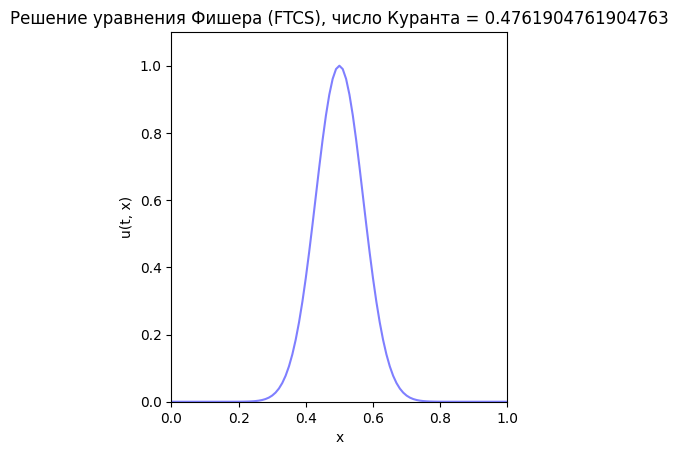

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('u(t, x)')
ax.set_title('Решение уравнения Фишера (FTCS),\nчисло Куранта = {}'.format(alpha))

line, = ax.plot(x, u[0, :], c='blue', alpha=0.5)

def animate(i, x, u):
    line.set_data(x, u[i, :])
    return line

ani = anim.FuncAnimation(fig, animate, frames=n_temporal // 50, interval=100, fargs=(x, u[::50],))

from IPython.display import HTML
HTML(ani.to_jshtml())

Решение уравнения стремится к $u \equiv 1$: популяция распространяется по всей области $x \in \left[0, 1\right]$; можно отметить, что сначала популяция в точке $x = 0.5$ уменьшается (из-за влияния диффузионного члена в уравнении), а затем увеличивается и доходит до 1.

Полунеявная схема Кранка-Николсона основана на усреднении по времени диффузионного члена:
$$\frac{u_i^{n+1} - u_i^n}{\tau} = D\,\frac{1}{2}\left[\frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{h^2} + \frac{u_{i+1}^{n} - 2u_i^{n} + u_{i-1}^{n}}{h^2}\right] + r\,u_i^n(1 - u_i^n).$$

Переносим неизвестные $u^{n+1}$ влево:
$$
-\frac{\alpha}{2} u_{i-1}^{n+1}
+ (1 + \alpha) u_i^{n+1}
- \frac{\alpha}{2} u_{i+1}^{n+1}
= u_i^n + \frac{\alpha}{2}(u_{i+1}^n - 2u_i^n + u_{i-1}^n)
+ \Delta t\,r\,u_i^n(1 - u_i^n),
$$
где $\alpha = D\frac{\tau}{h^2}$.

Таким образом, на каждом шаге $n \to n+1$ решается трёхдиагональная система для $u^{n+1}$.

In [135]:

def thomas_algorithm(a, b, c, d):
    n = len(d)
    c_prime = np.zeros(n)
    d_prime = np.zeros(n)
    x = np.zeros(n)

    # Прямой ход (forward elimination)
    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i] * c_prime[i-1]
        if i < n - 1:
            c_prime[i] = c[i] / denom
        d_prime[i] = (d[i] - a[i] * d_prime[i-1]) / denom

    # Обратный ход (back substitution)
    x[-1] = d_prime[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]

    return x

def crank_nicolson(u, D, r, dx, dt, n_temporal):
    alpha = D * dt / dx ** 2
    
    lower = np.zeros(n_spatial + 1)      # нижняя диагональ
    diag = np.zeros(n_spatial + 1)       # главная диагональ
    upper = np.zeros(n_spatial + 1)      # верхняя диагональ
    
    # Граничное условие Неймана на левом конце
    diag[0] = 1 + alpha
    upper[0] = -alpha
    
    # Внутренние точки
    for i in range(1, n_spatial):
        lower[i] = -alpha / 2
        diag[i] = 1 + alpha
        upper[i] = -alpha / 2
    
    # Граничное условие Неймана на правом конце
    lower[-1] = -alpha
    diag[-1] = 1 + alpha
    
    for n in range(n_temporal):
        rhs = np.zeros(n_spatial + 1)
        rhs[0] = (1 - alpha) * u[n, 0] + alpha * u[n, 1] + dt * r * u[n, 0] * (1 - u[n, 0])
        
        # Внутренние точки
        for i in range(1, n_spatial):
            rhs[i] = (alpha/2) * u[n, i-1] + (1 - alpha) * u[n, i] + (alpha/2) * u[n, i+1] + dt * r * u[n, i] * (1 - u[n, i])
        
        # Граничное условие Неймана на правом конце
        rhs[-1] = alpha * u[n, -2] + (1 - alpha) * u[n, -1] + dt * r * u[n, -1] * (1 - u[n, -1])
        
        # Решение трехдиагональной системы методом прогонки
        u[n + 1, :] = thomas_algorithm(lower, diag, upper, rhs)

    return u

In [136]:
u_cn = crank_nicolson(u_cn, D, r, h, dt, n_temporal)

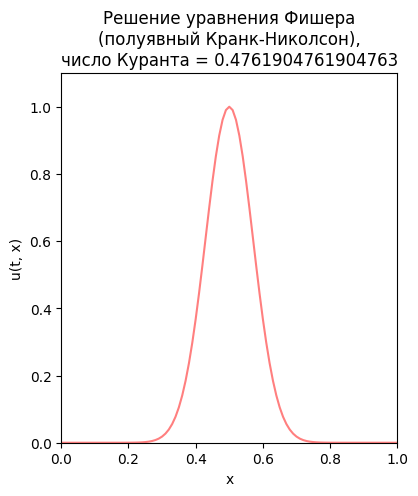

In [141]:
fig, ax = plt.subplots()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('u(t, x)')
ax.set_title('Решение уравнения Фишера\n(полуявный Кранк-Николсон),\nчисло Куранта = {}'.format(alpha))

line, = ax.plot(x, u_cn[0, :], c='red', alpha=0.5)

ani = anim.FuncAnimation(fig, animate, frames=n_temporal // 50, interval=100, fargs=(x, u_cn[::50],))

from IPython.display import HTML
HTML(ani.to_jshtml())

### Анализ влияния шага $\Delta t$ на устойчивость FTCS

In [172]:
n_spatial = 100
n_temporal = 900
alpha = 0.51

h = 1.0 / n_spatial
dt = alpha * h ** 2 / D
T = dt * n_temporal

x = np.linspace(0.0, 1.0, n_spatial + 1)
u = np.zeros((n_temporal + 1, n_spatial + 1))
u[0, :] = np.exp(-100 * (x - 0.5) ** 2)

In [173]:
u = ftcs(u, D, r, dt, h, n_spatial, n_temporal)

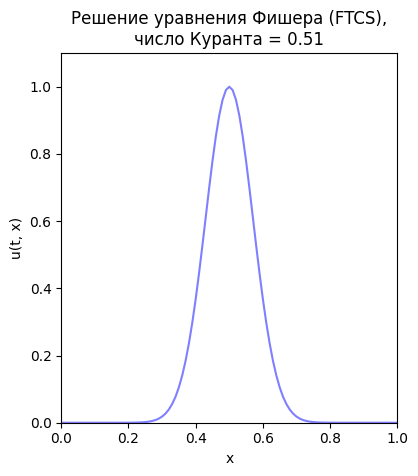

In [175]:
fig, ax = plt.subplots()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('u(t, x)')
ax.set_title('Решение уравнения Фишера (FTCS),\nчисло Куранта = {}'.format(alpha))

line, = ax.plot(x, u[0, :], c='blue', alpha=0.5)

def animate(i, x, u):
    line.set_data(x, u[i, :])
    return line

ani = anim.FuncAnimation(fig, animate, frames=n_temporal // 25, interval=100, fargs=(x, u[::25],))

from IPython.display import HTML
HTML(ani.to_jshtml())

In [180]:
n_temporal = 2000
alpha = 0.5

dt = alpha * h ** 2 / D
T = dt * n_temporal

u = np.zeros((n_temporal + 1, n_spatial + 1))
u[0, :] = np.exp(-100 * (x - 0.5) ** 2)

In [181]:
u = ftcs(u, D, r, dt, h, n_spatial, n_temporal)

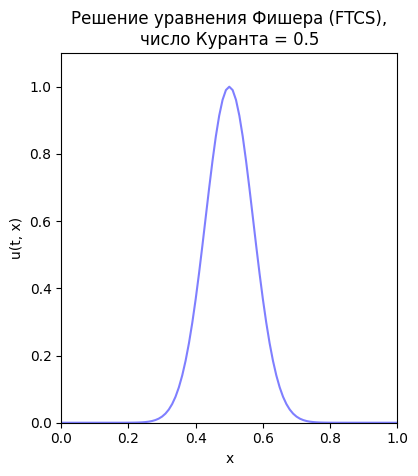

In [182]:
fig, ax = plt.subplots()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('u(t, x)')
ax.set_title('Решение уравнения Фишера (FTCS),\nчисло Куранта = {}'.format(alpha))

line, = ax.plot(x, u[0, :], c='blue', alpha=0.5)

def animate(i, x, u):
    line.set_data(x, u[i, :])
    return line

ani = anim.FuncAnimation(fig, animate, frames=n_temporal // 100, interval=100, fargs=(x, u[::100],))

from IPython.display import HTML
HTML(ani.to_jshtml())

Схема FTCS неустойчива при $\Delta t \gt \frac{1}{2} \frac{h^2}{D}$.